Before we start with **task 1**, add some more packages in the _Julia REPL_. Namely `Images` and `TestImages`. (They can be installed while we will be solving **task 1**.)

**Task 1** Let
$$ A = \begin{bmatrix} -1 & 1 & 2 \\ 1 & -1 & -2 \\ 1 & -1 & 2 \\ -1 & 1 & -2 \end{bmatrix}\textrm{, } \quad A' = \begin{bmatrix} -1 & 2 \\ 1 & -2 \\ 1 & 2 \\ -1 & -2 \end{bmatrix}\quad \textrm{ and }\quad \mathbf{b} = \begin{bmatrix} 3 \\ -3 \\ 2 \\ 0 \end{bmatrix}.$$

* Is the system $A\mathbf{x} = \mathbf{b}$ solvable? Is the system $A'\mathbf{x} = \mathbf{b}$ solvable? Find orthogonal projections $\mathbf{b}_1$ and $\mathbf{b}_1'$ of the vector $\mathbf{b}$ onto $C(A)$ and $C(A')$, and then find all the solutions of the systems $A \mathbf{x} = \mathbf{b}_1$ and $A' \mathbf{x} = \mathbf{b}_1'$.

* Find the singular value decomposition of $A$; $A=USV^\mathsf{T}$. This can be obtained using the eigenvalue decomposition of $A^\mathsf{T} A$. 

* Find the Moore--Penrose pseudoinverses of $A$ and $A'$, and evaluate $A^+\mathbf{b}$ and $A'^+\mathbf{b}$. Explain the result.
	
* Solve the exercise in _Julia_, using the commands `svd` and `pinv`. (Remember to load the `LinearAlgebra` package first.)

In [48]:
    #Sistem ni rešljiv namreč rang(A) < rang([A b]), prepričamo se lahko spodaj
    using  LinearAlgebra
    A = [-1 1 2;
          1 -1 2;
          1 -1 2;
         -1 1 -2]
    b = [3;-3;2;0]
    #Lahko tudi A\b pa preveris pol Ax-b, če je 0 oz blizu -> resljivo, sicer pa ni, prevers lohk tud z normo probs
    r1 = rank(A)
    println("Rang od A: ", r1)
    A_b = [A b]
    r2 = rank(A_b)
    println("Rang od razsirjene matrike [A b]: ", r2)
    
    A2 = [-1 2;
          1 -2;
          1 2;
          -1 -2]
    r11 = rank(A2)
    println("Rang od A': ", r11)
    A2_b = [A2 b]
    r22 = rank(A2_b)
    println("Rang od razsirjene matrike [A' b]: ", r22)
    
    function proj_CA(A, b)
        Q, R = qr(A)
        return Q * (Q' * b)
    end

    b1 = proj_CA(A, b);
    println("Projekcija b na C(A): ", b1)
    b2 = proj_CA(A2, b)
    println("Projekcija b na C(A'): ", b2)
    x1 = A\b1
    x2 = A2\b2
    println("Resitev Ax = b1: ", x1)
    println("Resitev A'x = b2: ", x2)

    U, E, VT = svd(A);
    

Rang od A: 2
Rang od razsirjene matrike [A b]: 3
Rang od A': 2
Rang od razsirjene matrike [A' b]: 3
Projekcija b na C(A): [2.9999999999999982, -2.9999999999999996, 1.9999999999999991, 0.0]
Projekcija b na C(A'): [2.999999999999999, -3.0, 2.0, -2.220446049250313e-16]
Resitev Ax = b1: [-0.8333333333333327, 0.8333333333333328, 0.6666666666666659]
Resitev A'x = b2: [-0.9999999999999999, 1.0]


**SVD and image compression.** A greyscale image can be represented by a matrix $A$. (A color image can be represented using three matrices, say $A_R$, $A_G$ and $A_B$). Using the matrices $U$, $S$, and $V$ from the SVD decomposition we can reconstruct the matrix $A$ by computing $U S V^\mathsf{T}$. Moreover, we can decide that small singular values contribute very little to the image and can be ignored. Let $S'$ be the matrix that contains the largest $m$ singular values on the diagonal. Then $A'=US'V^\mathsf{T}$ can serve as an approximation to $A$.

**Task 2** 
* Add packages `Images` and `TestImages`.
* Load one of the test images. 
* Find the SVD decompositions of $A_R$, $A_G$ and $A_B$.
* Compute the approximations for the image obtained by using 10, 20, 50, 100 of the largest singular values of the matrices $A_i$. Display the images and visually asses the quality of the compressed images.
* How much storage space would we actually need to store such an approximation?

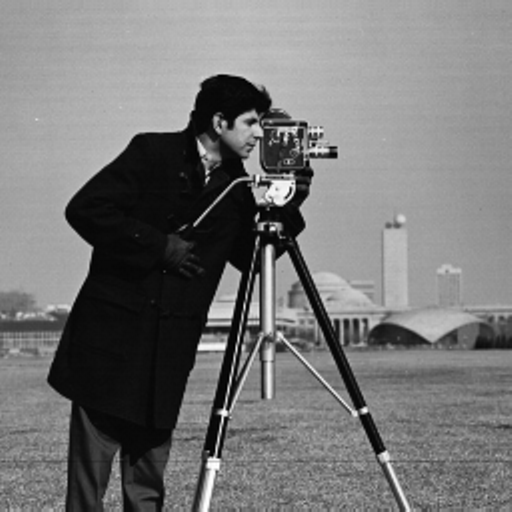

In [22]:
using Images
using TestImages

img = testimage("cameraman")


In [45]:
A = Float64.(img);
U, E, VT = svd(A);

,,,

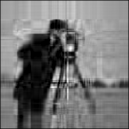
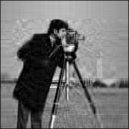
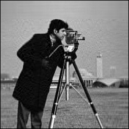
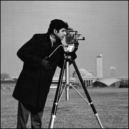

In [44]:
k = [10, 20, 50, 100]
slikeGray = [U[:, 1:ki]*Diagonal(E[1:ki])*VT[:, 1:ki]' for ki in k]
imgsGray = [Gray.(slikeGray[i]) for i in [1, 2, 3, 4]]


In [46]:
lena = testimage("lena");
A = channelview(lena);
R = Float64.(A[1, :, :]);
G = Float64.(A[2, :, :]);
B = Float64.(A[3, :, :]);

U1, E1, V1T = svd(R);
U2, E2, V2T = svd(G);
U3, E3, V3T = svd(B);
k = [k1, k2, k3, k4];

slikeR = [U1[:, 1:ki]*Diagonal(E1[1:ki])*V1T[:, 1:ki]' for ki in k];
slikeG = [U2[:, 1:ki]*Diagonal(E2[1:ki])*V2T[:, 1:ki]' for ki in k];
slikeB = [U3[:, 1:ki]*Diagonal(E3[1:ki])*V3T[:, 1:ki]' for ki in k];

,,,

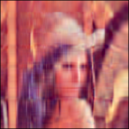
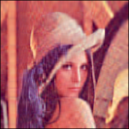
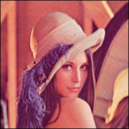
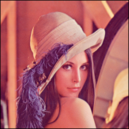

In [47]:
imgsRGB = [RGB.(slikeR[i], slikeG[i], slikeB[i]) for i in [1, 2, 3, 4]]

In [ ]:
#Za vnaprej, channelview -> iz RGB matrike ki je mxn pa vsebuje trojice (R,G,B) pretvori v tenzor 3xmxn, je lazje delat pol
#Obratna operacija je pa colorview()